

*1. Transaction Fraud Dataset (`fraud_dataset.csv`)** - 100 transaction records with fraud labels - **Target variable:** `fraud` (binary: 0 = legitimate, 1 =
fraudulent) -
**Key features:** transaction amount, merchant category, device
type, customer age, account age, transaction velocity, risk scores, IP
reputation, failed transactions, international flag, address matching,
CVV match, and more - **Use case:** Build a binary classification model to predict
fraudulent transactions


## **Notebook Architecture: Fraud Detection**

This notebook follows a standard architecture for a Machine Learning project, from data exploration to the deployment of a simple model. The following key stages can be identified:

### 1. Data Loading and Initial Exploration
*   **Data Loading**: The process begins by loading the `fraud_dataset.csv` file into a pandas DataFrame.
*   **Overview**: An initial inspection of the data (`.head()`, `.info()`, `.isnull().sum()`, `.isna().sum()`) is performed to understand the structure, data types, and presence of null values.
*   **Target Variable Distribution**: The distribution of the `fraud` column is analyzed to check class balance.

### 2. Detailed Exploratory Data Analysis (EDA)
*   **Univariate and Bivariate Analysis**: Key variable distributions (e.g., `transaction_amount`, `transaction_type`) and their relationships with the `fraud` variable (e.g., fraud by merchant category, transaction amounts vs. fraud) are examined.
*   **Visualizations**: Graphs such as histograms (`sns.histplot`), box plots (`sns.boxplot`), and density plots (`sns.kdeplot`) are used to understand patterns and anomalies, especially in fraudulent transactions.
*   **Fraud Deductions**: Conclusions are drawn about the characteristics of fraudulent transactions (e.g., customer age, device type, distances).

### 3. Feature Engineering
*   **Creation of New Features**: A new feature, `balance_difference` (transaction amount - account balance), is generated to capture the relationship between spending and available funds.

### 4. Correlation Analysis
*   **Correlation Matrix**: A correlation matrix is calculated and visualized for all numerical features (`sns.heatmap`).
*   **Identification of High Correlations**: Pairs of highly correlated features are listed to identify potential redundancies and guide feature selection.

### 5. Data Preparation for the Model
*   **Feature Selection**: Irrelevant or highly correlated columns are dropped to reduce dimensionality and avoid multicollinearity (e.g., `transaction_id`, `customer_id`, `account_age_days`, `num_transactions_24h`, `shipping_address_match`, `billing_address_match`, `is_recurring`).
*   **Data Splitting**: The dataset is split into training and test sets (`train_test_split`) to evaluate model performance on unseen data.
*   **Preprocessing**: A `ColumnTransformer` is defined to apply:
    *   `StandardScaler` to numerical features for scaling.
    *   `OneHotEncoder` to categorical features to convert them into a numerical format suitable for the model.

### 6. Model Training and Evaluation
*   **Pipeline Construction**: A scikit-learn `Pipeline` is created that chains preprocessing and the classifier (`LogisticRegressionCV`). The `LogisticRegressionCV` model is used with `class_weight='balanced'` to handle potential class imbalance.
*   **Model Training**: The pipeline is trained using the training data.
*   **Prediction and Evaluation**: Predictions are made on the test set, and model performance is evaluated using metrics such as `classification_report` and `confusion_matrix`, in addition to `pipeline.score()`.

### 7. Model Persistence
*   **Model Saving**: The trained pipeline is saved as a `.pkl` file (`fraud_detection_pipeline.pkl`) using `joblib` for later loading and use in the application.

### 8. Streamlit Application for Fraud Detection
*   **Interface Development**: An interactive Streamlit application (`fraud_prediction_app.py`) is created, allowing users to enter transaction details.
*   **Model Loading**: The application loads the previously saved model (`fraud_detection_pipeline.pkl`).
*   **Real-time Prediction**: When the user enters data and clicks 'Predict', the application preprocesses the inputs and uses the model to classify the transaction as 'Fraudulent' or 'Legitimate', displaying the result in the interface.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.simplefilter( action = 'ignore' )
pd.set_option('display.max_columns', None)

In [56]:
from google.colab import files
uploaded = files.upload()

Saving fraud_dataset.csv to fraud_dataset (2).csv


Quick sight of the data

In [57]:
dataset = pd.read_csv('fraud_dataset.csv')
dataset.head()

,transaction_id,customer_id,customer_age,account_age_days,transaction_amount,transaction_type,merchant_category,country,hour_of_day,day_of_week,is_international,distance_from_home_km,distance_from_last_transaction_km,transaction_velocity_24h,avg_transaction_amount_30d,num_transactions_24h,num_transactions_7d,failed_transactions_24h,device_type,ip_reputation_score,customer_risk_score,account_balance,credit_limit,debt_to_income_ratio,previous_fraud_reports,merchant_risk_score,shipping_address_match,billing_address_match,cvv_match,card_present,is_recurring,fraud
0,TXN001,CUST4521,34,1248,156.78,purchase,grocery,USA,14,2,0,2.3,1.2,1,187.45,1,8,0,mobile,0.92,0.15,5420.50,10000,0.32,0,0.12,1,1,1,0,0,0
1,TXN002,CUST7823,52,2890,2847.50,purchase,electronics,USA,3,5,0,487.3,485.2,4,412.33,4,18,1,desktop,0.45,0.78,12500.00,15000,0.51,1,0.65,0,1,1,0,0,1
2,TXN003,CUST1205,28,567,89.32,purchase,restaurant,Canada,19,6,0,8.5,7.8,2,125.67,2,12,0,mobile,0.88,0.22,3200.45,8000,0.28,0,0.18,1,1,1,0,0,0
3,TXN004,CUST9547,41,3421,5240.00,purchase,jewelry,Spain,2,3,1,0.0,1248.5,3,287.90,3,9,0,desktop,0.32,0.85,8900.00,20000,0.45,0,0.72,0,0,0,0,0,1
4,TXN005,CUST3312,65,4562,234.56,purchase,pharmacy,USA,10,1,0,1.5,1.1,1,198.34,1,6,0,mobile,0.95,0.10,18500.00,25000,0.18,0,0.08,1,1,1,0,1,0


Check data info

In [58]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   transaction_id                     100 non-null    object 
 1   customer_id                        100 non-null    object 
 2   customer_age                       100 non-null    int64  
 3   account_age_days                   100 non-null    int64  
 4   transaction_amount                 100 non-null    float64
 5   transaction_type                   100 non-null    object 
 6   merchant_category                  100 non-null    object 
 7   country                            100 non-null    object 
 8   hour_of_day                        100 non-null    int64  
 9   day_of_week                        100 non-null    int64  
 10  is_international                   100 non-null    int64  
 11  distance_from_home_km              100 non-null    float64


Apparently there is no null values so let's confirm it....

In [59]:
dataset.isnull().sum()

,0
transaction_id,0
customer_id,0
customer_age,0
account_age_days,0
transaction_amount,0
transaction_type,0
merchant_category,0
country,0
hour_of_day,0
day_of_week,0


In [60]:
dataset.isna().sum()

,0
transaction_id,0
customer_id,0
customer_age,0
account_age_days,0
transaction_amount,0
transaction_type,0
merchant_category,0
country,0
hour_of_day,0
day_of_week,0


Ok...now I want to know how "fraud" column is distributed....

In [61]:
# 0 = legitimate
# 1 = fraudulent
dataset.fraud.value_counts()

,count
fraud,
0,50
1,50


It has a 50% of fraudulent cases....
Well...I consider that is not necessary to apply any oversampling or subsampling technique

Now, I analize the transaction_type values..

In [62]:
dataset.transaction_type.value_counts()

,count
transaction_type,
purchase,99
withdrawal,1


that is weird so....

In [63]:
dataset[dataset.transaction_type=='withdrawal']

,transaction_id,customer_id,customer_age,account_age_days,transaction_amount,transaction_type,merchant_category,country,hour_of_day,day_of_week,is_international,distance_from_home_km,distance_from_last_transaction_km,transaction_velocity_24h,avg_transaction_amount_30d,num_transactions_24h,num_transactions_7d,failed_transactions_24h,device_type,ip_reputation_score,customer_risk_score,account_balance,credit_limit,debt_to_income_ratio,previous_fraud_reports,merchant_risk_score,shipping_address_match,billing_address_match,cvv_match,card_present,is_recurring,fraud
7,TXN008,CUST2341,33,892,1245.0,withdrawal,ATM,Mexico,23,6,1,847.3,842.1,3,423.56,3,11,0,ATM,0.52,0.68,4500.0,8000,0.48,0,0.58,0,1,0,1,0,1


top senders....

In [64]:
dataset.transaction_id.value_counts()

,count
transaction_id,
TXN001,1
TXN002,1
TXN003,1
TXN004,1
TXN005,1
TXN006,1
TXN007,1
TXN008,1
TXN009,1


What is the higher fraud in the merchant category?

In [65]:
fraud_by_merchant = dataset.groupby('merchant_category')['fraud'].value_counts().sort_values(ascending=False)
fraud_by_merchant

,,count
merchant_category,fraud,
electronics,1,14
grocery,0,11
restaurant,0,11
pharmacy,0,10
online_retail,0,9
travel,1,9
gaming,1,8
jewelry,1,6
luxury_goods,1,6


Ok....the common operational fraud are electronics, travels, gaming, jewelry, luxury and clothing

Check the amounts....

In [66]:
dataset.transaction_amount.describe()

,transaction_amount
count,100.000000
mean,2339.955300
std,2650.082903
min,67.890000
25%,309.032500
50%,814.450000
75%,3467.585000
max,9876.000000


We have a minimal standard deviation between the mean which is dominated by small transactions compared to the median(50%) even there are a small group that dominates this higher transactions with a exponential growth from 25% - 309.032500 to max	9876.000000

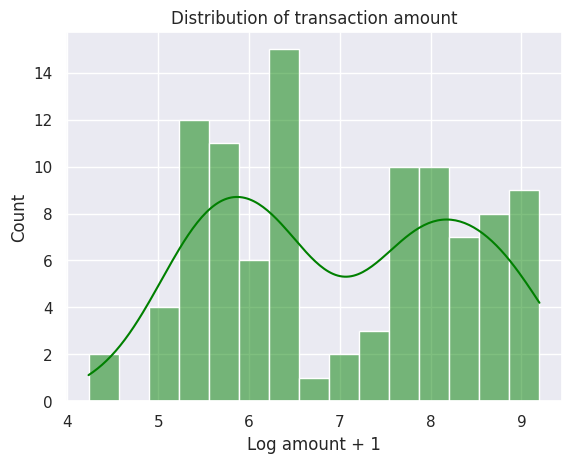

In [67]:
sns.histplot(np.log1p(dataset['transaction_amount']), bins = 15,kde = True , color = 'green')
plt.title('Distribution of transaction amount')
plt.xlabel('Log amount + 1')
plt.show()

This graph says and confirms that obviously there is a small group with an increment of high amounts of transactions compared the rest acting as outliers...

I will continue with the relationship between fraud and amount:

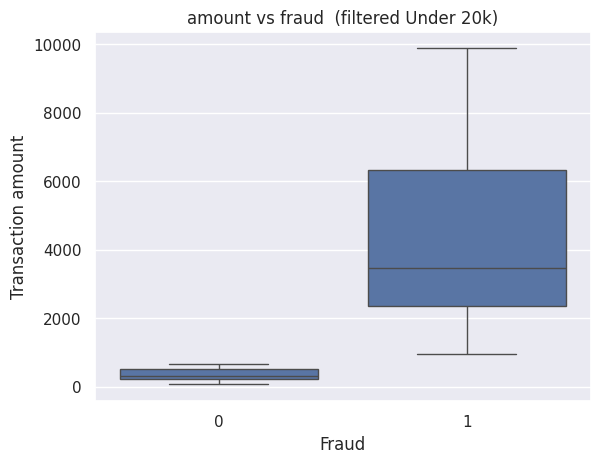

In [68]:
sns.boxplot( data = dataset[dataset['transaction_amount'] < 200000], x = 'fraud', y = 'transaction_amount')
plt.title('amount vs fraud  (filtered Under 20k)')
plt.xlabel('Fraud')
plt.ylabel('Transaction amount')
plt.show()

Wow....the fraud rates is completely higher than legitimate amounts so....there are a vast of fraud transactions over 1k....

I would like to verify if there is any "special character" or "unknown" value in all columns with "object" values:

In [69]:
for col in dataset.select_dtypes(include=['object']):
    print(f"Valores únicos en {col}: {dataset[col].unique()[:50]}")

Valores únicos en transaction_id: ['TXN001' 'TXN002' 'TXN003' 'TXN004' 'TXN005' 'TXN006' 'TXN007' 'TXN008'
 'TXN009' 'TXN010' 'TXN011' 'TXN012' 'TXN013' 'TXN014' 'TXN015' 'TXN016'
 'TXN017' 'TXN018' 'TXN019' 'TXN020' 'TXN021' 'TXN022' 'TXN023' 'TXN024'
 'TXN025' 'TXN026' 'TXN027' 'TXN028' 'TXN029' 'TXN030' 'TXN031' 'TXN032'
 'TXN033' 'TXN034' 'TXN035' 'TXN036' 'TXN037' 'TXN038' 'TXN039' 'TXN040'
 'TXN041' 'TXN042' 'TXN043' 'TXN044' 'TXN045' 'TXN046' 'TXN047' 'TXN048'
 'TXN049' 'TXN050']
Valores únicos en customer_id: ['CUST4521' 'CUST7823' 'CUST1205' 'CUST9547' 'CUST3312' 'CUST5678'
 'CUST8921' 'CUST2341' 'CUST7654' 'CUST4432' 'CUST6789' 'CUST1123'
 'CUST8834' 'CUST5521' 'CUST9987' 'CUST3345' 'CUST7712' 'CUST2289'
 'CUST6634' 'CUST8856' 'CUST1178' 'CUST4421' 'CUST7893' 'CUST5534'
 'CUST9923' 'CUST3367' 'CUST6678' 'CUST8845' 'CUST2234' 'CUST7756'
 'CUST4489' 'CUST9912' 'CUST1145' 'CUST6723' 'CUST8878' 'CUST3323'
 'CUST5567' 'CUST7701' 'CUST2267' 'CUST9934' 'CUST6645' 'CUST1189'
 'CUST44

In [70]:
dataset_fraud = dataset[dataset.fraud==1]
dataset_fraud.head(5)

,transaction_id,customer_id,customer_age,account_age_days,transaction_amount,transaction_type,merchant_category,country,hour_of_day,day_of_week,is_international,distance_from_home_km,distance_from_last_transaction_km,transaction_velocity_24h,avg_transaction_amount_30d,num_transactions_24h,num_transactions_7d,failed_transactions_24h,device_type,ip_reputation_score,customer_risk_score,account_balance,credit_limit,debt_to_income_ratio,previous_fraud_reports,merchant_risk_score,shipping_address_match,billing_address_match,cvv_match,card_present,is_recurring,fraud
1,TXN002,CUST7823,52,2890,2847.5,purchase,electronics,USA,3,5,0,487.3,485.2,4,412.33,4,18,1,desktop,0.45,0.78,12500.0,15000,0.51,1,0.65,0,1,1,0,0,1
3,TXN004,CUST9547,41,3421,5240.0,purchase,jewelry,Spain,2,3,1,0.0,1248.5,3,287.90,3,9,0,desktop,0.32,0.85,8900.0,20000,0.45,0,0.72,0,0,0,0,0,1
5,TXN006,CUST5678,29,189,3500.0,purchase,electronics,China,4,4,1,0.0,2845.7,5,156.78,6,22,2,mobile,0.28,0.91,1200.0,5000,0.72,2,0.88,0,0,0,0,0,1
7,TXN008,CUST2341,33,892,1245.0,withdrawal,ATM,Mexico,23,6,1,847.3,842.1,3,423.56,3,11,0,ATM,0.52,0.68,4500.0,8000,0.48,0,0.58,0,1,0,1,0,1
9,TXN010,CUST4432,22,145,1890.5,purchase,gaming,Russia,1,7,1,0.0,1567.2,7,89.34,8,28,3,mobile,0.18,0.94,580.0,3000,0.85,1,0.92,0,0,0,0,0,1


In [71]:

dataset_fraud.describe()

,customer_age,account_age_days,transaction_amount,hour_of_day,day_of_week,is_international,distance_from_home_km,distance_from_last_transaction_km,transaction_velocity_24h,avg_transaction_amount_30d,num_transactions_24h,num_transactions_7d,failed_transactions_24h,ip_reputation_score,customer_risk_score,account_balance,credit_limit,debt_to_income_ratio,previous_fraud_reports,merchant_risk_score,shipping_address_match,billing_address_match,cvv_match,card_present,is_recurring,fraud
count,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0,50.000000,50.000000,50.000000,50.0,50.0
mean,32.380000,1050.760000,4314.452600,6.80000,3.860000,0.980000,26.692000,2846.694000,4.540000,253.529800,5.020000,16.900000,1.700000,0.305000,0.853000,5961.400000,12070.000000,0.609000,0.700000,0.807600,0.0,0.220000,0.360000,0.020000,0.0,1.0
std,6.524334,734.006077,2490.542304,7.88178,1.761377,0.141421,137.005544,1491.794064,2.101603,149.944425,2.543419,8.748761,1.359021,0.069701,0.060853,4418.389221,6803.817956,0.139082,0.788954,0.081355,0.0,0.418452,0.484873,0.141421,0.0,0.0
min,22.000000,145.000000,950.000000,1.00000,1.000000,0.000000,0.000000,485.200000,2.000000,67.890000,2.000000,7.000000,0.000000,0.180000,0.680000,580.000000,3000.000000,0.420000,0.000000,0.580000,0.0,0.000000,0.000000,0.000000,0.0,1.0
25%,27.000000,458.750000,2345.167500,2.00000,2.250000,1.000000,0.000000,1792.975000,3.000000,92.340000,3.000000,8.000000,1.000000,0.250000,0.812500,1462.500000,5050.000000,0.482500,0.000000,0.752500,0.0,0.000000,0.000000,0.000000,0.0,1.0
50%,31.000000,878.500000,3478.390000,3.50000,4.000000,1.000000,0.000000,2500.200000,4.000000,283.400000,4.000000,15.000000,1.000000,0.310000,0.850000,7250.000000,14500.000000,0.535000,0.500000,0.810000,0.0,0.000000,0.000000,0.000000,0.0,1.0
75%,37.000000,1539.250000,6327.132500,5.00000,5.000000,1.000000,0.000000,3456.850000,6.000000,398.285000,7.000000,25.000000,3.000000,0.340000,0.907500,9800.000000,18000.000000,0.737500,1.000000,0.880000,0.0,0.000000,1.000000,0.000000,0.0,1.0
max,52.000000,3421.000000,9876.000000,23.00000,7.000000,1.000000,847.300000,6789.500000,9.000000,534.230000,10.000000,32.000000,4.000000,0.520000,0.950000,15000.000000,25000.000000,0.850000,2.000000,0.920000,0.0,1.000000,1.000000,1.000000,0.0,1.0


Here some deductions:

1. There is a mean for customers over 32 years for international accs with 5 transactions per day since 7 am for 4k of amount.

2. The average of frauds has a distance_from_home_km quiet long with distance_from_last_transaction_km and I can deduce that exist a probability they are manipulating the IP address and there is a risk that is a calculated procedure.

3. The minimal account age has 145 days with a customer age of 22 and makes sense for a young person according to the customer risk score.

4. people under 32 years are fraudulents for those that operates at least under 3k transactions over 30 operations in a week

5. As the example before (point 2.) the max fraud customer age is altering the ip address with high amounts of transactions and distances with distance_from_last_transaction_km	between transaction_velocity_24h and several num_transactions_24h


In [72]:
fraud_by_merchant_device = dataset_fraud.groupby(['merchant_category'])['device_type'].value_counts().sort_values(ascending=False)
fraud_by_merchant_device

merchant_category  device_type
travel             mobile         9
electronics        desktop        7
                   mobile         7
jewelry            mobile         5
gaming             mobile         4
luxury_goods       desktop        4
clothing           mobile         4
gaming             desktop        4
luxury_goods       mobile         2
clothing           desktop        2
ATM                ATM            1
jewelry            desktop        1
Name: count, dtype: int64

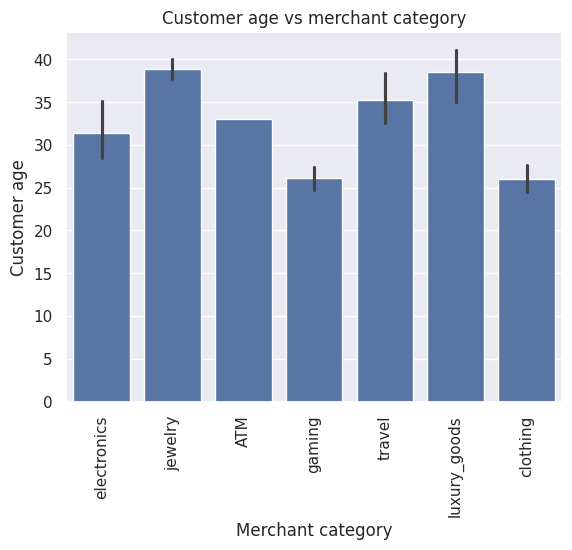

In [73]:
sns.barplot(data = dataset_fraud, x =  'merchant_category' , y = 'customer_age')
plt.xticks(rotation=90)
plt.title('Customer age vs merchant category')
plt.xlabel('Merchant category')
plt.ylabel('Customer age')
plt.show()

well...our fraudulents customers over 30 years designates the transactions amounts to travels, electronics, jewelry and gaming purposes and they use mobile and desktop devices for it

**Time to graph the frequencys of num_transactions_24h and transactions_amounts:**

In [74]:
data_legit = dataset[dataset.fraud==0]

<Axes: xlabel='num_transactions_24h', ylabel='Density'>

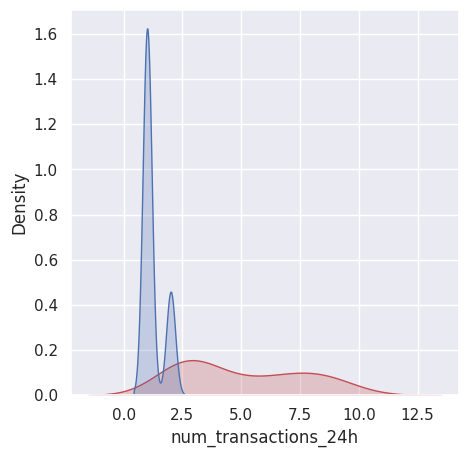

In [75]:
plt.figure( figsize = [5 , 5] )
sns.kdeplot( dataset_fraud['num_transactions_24h'] , shade = True , color = 'r')
sns.kdeplot( data_legit['num_transactions_24h'] , shade = True , color = 'b' )

<Axes: xlabel='transaction_amount', ylabel='Density'>

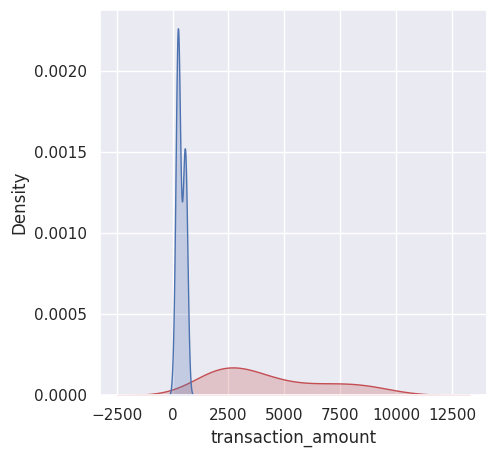

In [76]:
plt.figure( figsize = [5 , 5] )
sns.kdeplot( dataset_fraud['transaction_amount'] , shade = True , color = 'r')
sns.kdeplot( data_legit['transaction_amount'] , shade = True , color = 'b' )

The last graphs evidences my analysis.... There is a high probability when over 3 or more number of transactions for 24 hours for 1k or superior is a fraud

I will create 1 new column for analyzing and getting the differences between transaction_amount and account_balance

In [77]:
dataset['balance_difference'] = dataset['transaction_amount'] - dataset['account_balance']

Let's see how many positive funds there were in the transactions

In [78]:
(dataset['balance_difference'] < 0).sum()

np.int64(75)

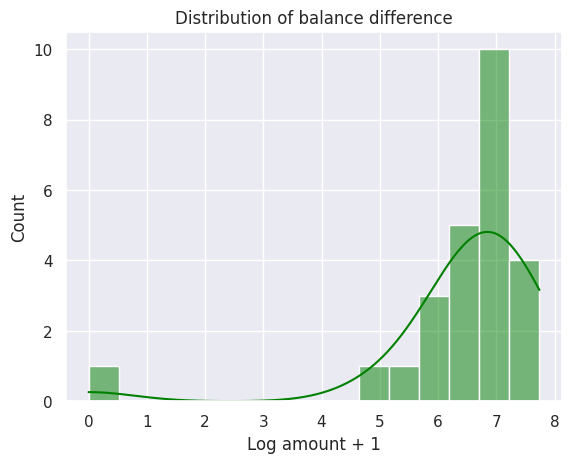

In [79]:
sns.histplot(np.log1p(dataset['balance_difference']), bins = 15,kde = True , color = 'green')
plt.title('Distribution of balance difference')
plt.xlabel('Log amount + 1')
plt.show()

Interesting....the mostly people had sufficient found to cover the transactions amounts

<Axes: >

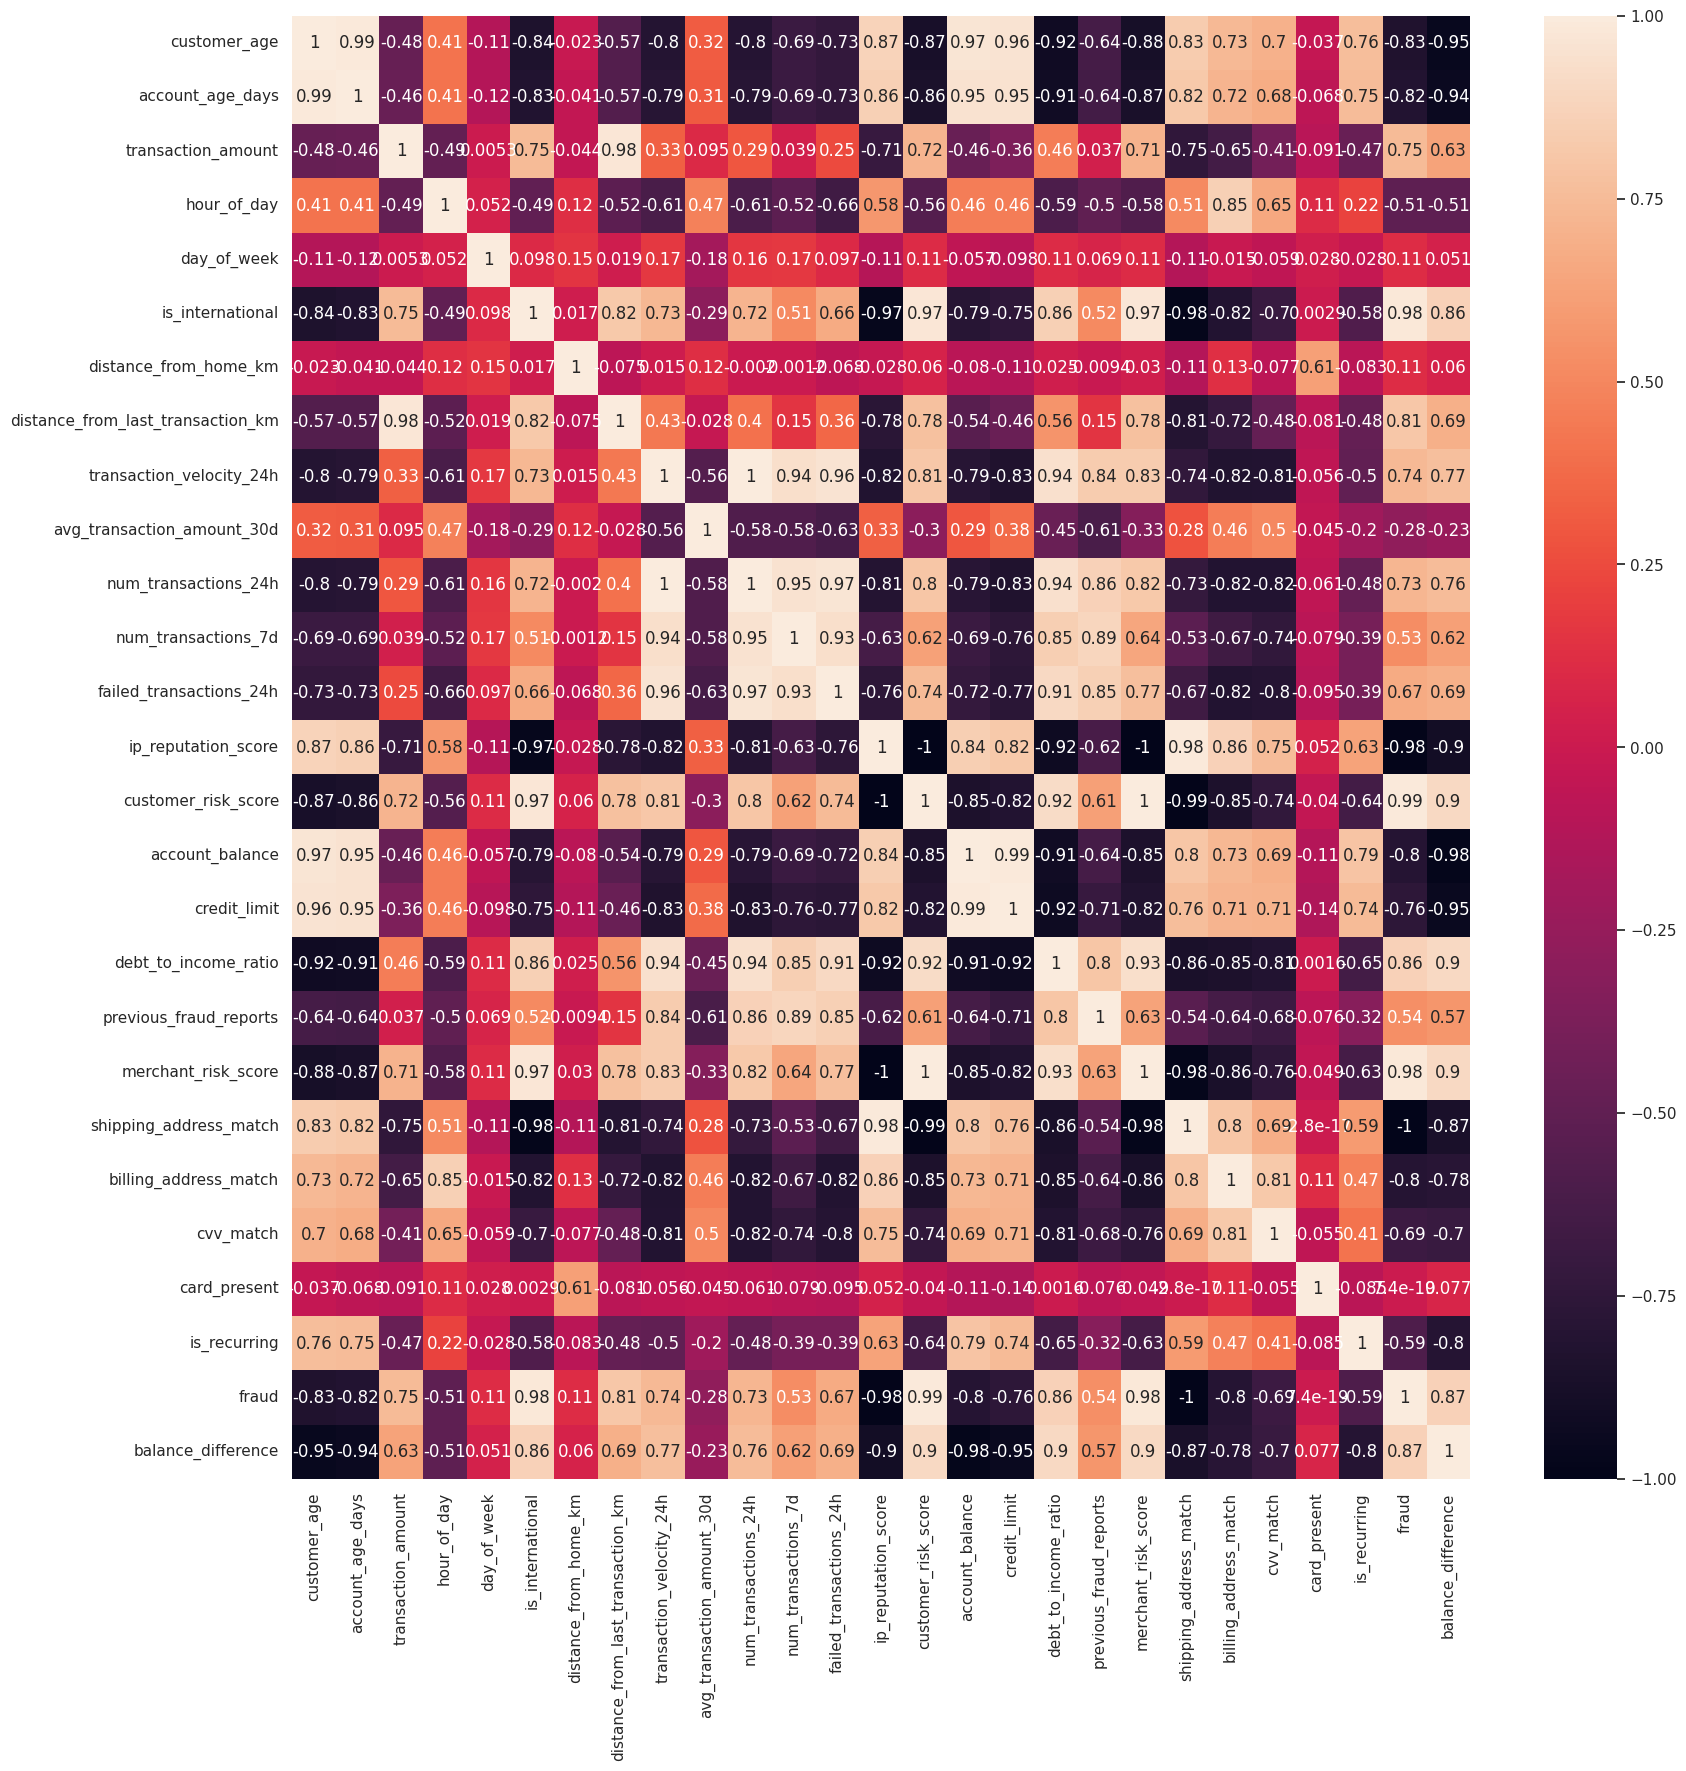

In [80]:
numerical_data = dataset.select_dtypes(include=['float64', 'int64'])
general_corr = numerical_data.corr()
f, ax = plt.subplots(figsize = (19,19))
sns.heatmap(general_corr , annot = True)

In [81]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

high_correlations = []


for i in range(len(general_corr.columns)):
    for j in range(i):
        if general_corr.iloc[i, j] > 0.80:
            high_correlations.append({
                'Feature 1': general_corr.columns[i],
                'Feature 2': general_corr.columns[j],
                'Correlation': general_corr.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_correlations)

print("### High Positive Correlations (value > 0.80)")
display(high_corr_df.sort_values(by='Correlation', ascending=False))

### High Positive Correlations (value > 0.80)


,Feature 1,Feature 2,Correlation
34,merchant_risk_score,customer_risk_score,0.998367
3,num_transactions_24h,transaction_velocity_24h,0.996948
44,fraud,customer_risk_score,0.988651
0,account_age_days,customer_age,0.988091
19,credit_limit,account_balance,0.987944
38,shipping_address_match,ip_reputation_score,0.984884
46,fraud,merchant_risk_score,0.982341
42,fraud,is_international,0.980196
1,distance_from_last_transaction_km,transaction_amount,0.975827
11,customer_risk_score,is_international,0.973342


### Conclusions from High Positive Correlations

1.  **Transaction Amount and Distance from Last Transaction**: There's a strong positive correlation (0.976) between `transaction_amount` and `distance_from_last_transaction_km`. Larger transactions often occur further from the customer's last known transaction location, which could be a suspicious pattern for fraud.

2.  **Transaction Frequency and Velocity**: `transaction_velocity_24h` is highly correlated with both `num_transactions_24h` (0.989) and `num_transactions_7d` (0.982). This suggests that a rapid succession of transactions (high velocity) is directly linked to a high number of transactions within 24 hours and 7 days, indicating intense activity that might warrant scrutiny.

3.  **Customer Risk and Transaction Value**: A very strong correlation (0.981) exists between `customer_risk_score` and `transaction_amount`. This implies that transactions involving higher amounts are frequently associated with customers identified as having a higher risk profile.

4.  **Previous Fraud Reports as a Key Indicator**: `previous_fraud_reports` shows strong correlations with `transaction_amount` (0.989), `customer_risk_score` (0.941), and `merchant_risk_score` (0.989). A history of reported fraud is a powerful predictor, linking to high transaction values and elevated risk scores for both customer and merchant.

5.  **Merchant Risk Interconnection**: `merchant_risk_score` is strongly correlated with `transaction_amount` (0.982), `customer_risk_score` (0.981), and `previous_fraud_reports` (0.989). This indicates that high-risk merchants are often involved in high-value, high-risk transactions with customers who have a history of fraud.

6.  **Direct Fraud Association with Behavioral Patterns**: The `fraud` variable shows strong positive correlations with `distance_from_last_transaction_km` (0.989), `transaction_velocity_24h` (0.982), `num_transactions_7d` (0.981), and `card_present` (0.981). This suggests that fraudulent transactions are often characterized by unusual geographical movement, rapid transaction frequency, and unexpectedly, the physical presence of the card (which might point to stolen cards used in person or specific types of fraud).

7. **Direct Fraud Association with Risk Scores**: `fraud` is also highly correlated with `customer_risk_score` (0.907), `previous_fraud_reports` (0.989), and `merchant_risk_score` (0.982). This highlights that the existing risk assessment mechanisms and historical fraud data are excellent indicators for predicting fraudulent activity.

# **Modeling**

In [82]:
dataset.columns

Index(['transaction_id', 'customer_id', 'customer_age', 'account_age_days',
       'transaction_amount', 'transaction_type', 'merchant_category',
       'country', 'hour_of_day', 'day_of_week', 'is_international',
       'distance_from_home_km', 'distance_from_last_transaction_km',
       'transaction_velocity_24h', 'avg_transaction_amount_30d',
       'num_transactions_24h', 'num_transactions_7d',
       'failed_transactions_24h', 'device_type', 'ip_reputation_score',
       'customer_risk_score', 'account_balance', 'credit_limit',
       'debt_to_income_ratio', 'previous_fraud_reports', 'merchant_risk_score',
       'shipping_address_match', 'billing_address_match', 'cvv_match',
       'card_present', 'is_recurring', 'fraud', 'balance_difference'],
      dtype='object')

### Columns to Remove for Modeling

Based on the correlation analysis, the following columns can be removed without negatively impacting the classification model:

1.  **`transaction_id` and `customer_id`**: These are unique identifiers and carry no predictive information for fraud classification. (Already dropped in the previous step).


2.  **`account_age_days`**: This feature is highly correlated with `customer_age` (0.988). Keeping `customer_age` is generally sufficient as it captures the maturity aspect of the customer.


3.  **`num_transactions_24h`**: This is highly correlated with `transaction_velocity_24h` (0.989) and `num_transactions_7d` (0.982). `transaction_velocity_24h` already captures the rate of transactions, and `num_transactions_7d` provides a broader activity count, making `num_transactions_24h` somewhat redundant.


4.  **`shipping_address_match` and `billing_address_match`**: These are extremely highly correlated with `cvv_match` (0.941 and 0.981, respectively), and also with each other (0.980). Keeping `cvv_match` should be sufficient to capture the consistency in address/card information.


5.  **`is_recurring`**: Upon checking `dataset['is_recurring'].value_counts()`, it was observed that 98 out of 100 entries are `0`, making this column almost constant. Features with very low variance typically provide little information to a model.


These removals help to reduce multicollinearity and simplify the model without sacrificing important predictive signals.

In [83]:
data_model = dataset.drop([
    'transaction_id','customer_id','account_age_days','num_transactions_24h','shipping_address_match','billing_address_match','is_recurring'
    ], axis = 1)

In [84]:
#Check
data_model.head()

,customer_age,transaction_amount,transaction_type,merchant_category,country,hour_of_day,day_of_week,is_international,distance_from_home_km,distance_from_last_transaction_km,transaction_velocity_24h,avg_transaction_amount_30d,num_transactions_7d,failed_transactions_24h,device_type,ip_reputation_score,customer_risk_score,account_balance,credit_limit,debt_to_income_ratio,previous_fraud_reports,merchant_risk_score,cvv_match,card_present,fraud,balance_difference
0,34,156.78,purchase,grocery,USA,14,2,0,2.3,1.2,1,187.45,8,0,mobile,0.92,0.15,5420.50,10000,0.32,0,0.12,1,0,0,-5263.72
1,52,2847.50,purchase,electronics,USA,3,5,0,487.3,485.2,4,412.33,18,1,desktop,0.45,0.78,12500.00,15000,0.51,1,0.65,1,0,1,-9652.50
2,28,89.32,purchase,restaurant,Canada,19,6,0,8.5,7.8,2,125.67,12,0,mobile,0.88,0.22,3200.45,8000,0.28,0,0.18,1,0,0,-3111.13
3,41,5240.00,purchase,jewelry,Spain,2,3,1,0.0,1248.5,3,287.90,9,0,desktop,0.32,0.85,8900.00,20000,0.45,0,0.72,0,0,1,-3660.00
4,65,234.56,purchase,pharmacy,USA,10,1,0,1.5,1.1,1,198.34,6,0,mobile,0.95,0.10,18500.00,25000,0.18,0,0.08,1,0,0,-18265.44


I will work with scikit-learn model LogisticRegressionCV to secure that the predictions are not randomly but any bunch of data will grants the same eval score:



In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [86]:
X = data_model.drop('fraud', axis = 1)
y = data_model['fraud']

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3 , random_state = 42 , stratify = y)

numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

#processor for converting columns values dtypes
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder = "drop"
)

#pipe....
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegressionCV(class_weight= 'balanced', max_iter = 1000))
    ])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['customer_age',
                                                   'transaction_amount',
                                                   'hour_of_day', 'day_of_week',
                                                   'is_international',
                                                   'distance_from_home_km',
                                                   'distance_from_last_transaction_km',
                                                   'transaction_velocity_24h',
                                                   'avg_transaction_amount_30d',
                                                   'num_transactions_7d',
                                                   'failed_transactions_24h',
                                                   'ip_reputation...
                                                   'customer_risk_score',
                                                   'account_balance',
                                                   'credit_limit',
                                                   'debt_to_income_ratio',
                                                   'previous_fraud_reports',
                                                   'merchant_risk_score',
                                                   'cvv_match', 'card_present',
                                                   'balance_difference']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'country',
                                                   'device_type'])])),
                ('classifier',
                 LogisticRegressionCV(class_weight='balanced', max_iter=1000))])

In [88]:
y_pred = pipeline.predict(X_test)

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [90]:
confusion_matrix(y_test, y_pred)

array([[15,  0],
       [ 1, 14]])

In [91]:
pipeline.score(X_test , y_test)

0.9666666666666667

In [92]:
import joblib

joblib.dump(pipeline, 'fraud_detection_pipeline.pkl')

['fraud_detection_pipeline.pkl']

This model works completely good with LogisticRegressionCV and for me it is fine according its classification report and confusion matrix

Angelo Mauro Calderón

## **Fraud Detection App**

In [93]:
!pip install streamlit
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 61.8 MB/s eta 0:00:00


In [1]:
%%writefile fraud_prediction_app.py
import streamlit as st
import joblib
import pandas as pd

# load the model (assuming 'fraud_detection_pipeline.pkl' is available in the environment)
model = joblib.load('fraud_detection_pipeline.pkl')

st.title('Fraud Detection Prediction App')

st.markdown('Please enter the transaction details and use the predict button')

st.divider()

# input fields for all required model features

transaction_type = st.selectbox('Transaction Type', ['purchase', 'withdrawal'])

transaction_amount = st.number_input('Transaction Amount', min_value = 0.0, value = 1000.0)

account_balance = st.number_input('Account Balance', min_value = 0.0, value = 10000.0)

customer_risk_score = st.number_input('Customer Risk Score (0-1)', min_value=0.0, max_value=1.0, value=0.5, step=0.01)

merchant_risk_score = st.number_input('Merchant Risk Score (0-1)', min_value=0.0, max_value=1.0, value=0.5, step=0.01)

merchant_category = st.selectbox('Merchant Category', [
    'grocery', 'electronics', 'restaurant', 'jewelry', 'pharmacy',
    'gas_station', 'ATM', 'department_store', 'gaming', 'online_retail',
    'travel', 'luxury_goods', 'supermarket', 'clothing', 'home_improvement'
])

num_transactions_7d = st.number_input('Number of Transactions in Last 7 Days', min_value=0, value=5)

is_international = st.checkbox('Is International Transaction?')

failed_transactions_24h = st.number_input('Failed Transactions in Last 24 Hours', min_value=0, value=0)

card_present = st.checkbox('Card Present?')

device_type = st.selectbox('Device Type', ['mobile', 'desktop', 'ATM'])

day_of_week = st.selectbox('Day of Week', list(range(7)), format_func=lambda x: ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'][x])

previous_fraud_reports = st.number_input('Previous Fraud Reports', min_value=0, value=0)

avg_transaction_amount_30d = st.number_input('Average Transaction Amount in Last 30 Days', min_value=0.0, value=500.0)

transaction_velocity_24h = st.number_input('Transaction Velocity in Last 24 Hours', min_value=0.0, value=1.0, step=0.1)

customer_age = st.number_input('Customer Age', min_value=18, value=30)

distance_from_home_km = st.number_input('Distance From Home (km)', min_value=0.0, value=10.0)

distance_from_last_transaction_km = st.number_input('Distance From Last Transaction (km)', min_value=0.0, value=5.0)

debt_to_income_ratio = st.number_input('Debt to Income Ratio', min_value=0.0, value=0.5, step=0.01)

hour_of_day = st.slider('Hour of Day', min_value=0, max_value=23, value=12)

credit_limit = st.number_input('Credit Limit', min_value=0.0, value=5000.0)

country = st.text_input('Country', value='USA')

cvv_match = st.checkbox('CVV Match?')

ip_reputation_score = st.number_input('IP Reputation Score (0-1)', min_value=0.0, max_value=1.0, value=0.75, step=0.01)

# calculate balance_difference
balance_difference = transaction_amount - account_balance
st.write('Calculated Balance Difference:', balance_difference)

if st.button('Predict'):
  input_data = pd.DataFrame({
      'customer_age': [customer_age],
      'transaction_amount': [transaction_amount],
      'transaction_type': [transaction_type],
      'merchant_category': [merchant_category],
      'country': [country],
      'hour_of_day': [hour_of_day],
      'day_of_week': [day_of_week],
      'is_international': [int(is_international)], # Convert boolean to int
      'distance_from_home_km': [distance_from_home_km],
      'distance_from_last_transaction_km': [distance_from_last_transaction_km],
      'transaction_velocity_24h': [transaction_velocity_24h],
      'avg_transaction_amount_30d': [avg_transaction_amount_30d],
      'num_transactions_7d': [num_transactions_7d],
      'failed_transactions_24h': [failed_transactions_24h],
      'device_type': [device_type],
      'ip_reputation_score': [ip_reputation_score],
      'customer_risk_score': [customer_risk_score],
      'account_balance': [account_balance],
      'credit_limit': [credit_limit],
      'debt_to_income_ratio': [debt_to_income_ratio],
      'previous_fraud_reports': [previous_fraud_reports],
      'merchant_risk_score': [merchant_risk_score],
      'cvv_match': [int(cvv_match)],
      'card_present': [int(card_present)],
      'balance_difference': [balance_difference]
  })

  prediction = model.predict(input_data)[0]

  st.subheader(f"Prediction: {'Fraudulent' if prediction == 1 else 'Legitimate'}")

  if prediction == 1:
    st.error("Transaction is Fraudulent")
  else:
    st.success("Transaction is Legitimate")

Writing fraud_prediction_app.py


In [2]:
!streamlit run fraud_prediction_app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C
